In [ ]:
import time, random, re, collections, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [ ]:
def set_seed(s=0):
  random.seed(s);np.random.seed(s)
  torch.manual_seed(s);torch.cuda.manual_seed_all(s)

In [ ]:
set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if device.type == 'cuda':
  print('GPU :',torch.cuda.get_device_name(0))

Device: cuda
GPU : Tesla T4


In [ ]:
from datasets import load_dataset

In [ ]:
raw = load_dataset('stanfordnlp/imdb')
set_seed(0)
train_raw = raw['train'].shuffle(seed=0).select(range(8000))
test_raw  = raw['test'].shuffle(seed=0).select(range(2000))
print('train reviews:', len(train_raw), '| test reviews:', len(test_raw))
print('example label (1=pos, 0=neg):', train_raw[0]['label'])
print('example text:', train_raw[0]['text'][:200], '...')

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

train reviews: 8000 | test reviews: 2000
example label (1=pos, 0=neg): 1
example text: We always watch American movies with their particular accents from each region (south, west, etc). We have the same here. All foreign people must to watch this movie and need to have a open mind to ac ...


In [ ]:
TOKEN_RE = re.compile(r"[a-z']+")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

In [ ]:
PAD, UNK = 0, 1
VOCAB_SIZE = 20000
MAX_LEN = 300

counter = collections.Counter()
for ex in train_raw:
    counter.update(tokenize(ex['text']))

itos = ['<pad>', '<unk>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 2)]
stoi = {w: i for i, w in enumerate(itos)}
print('vocab size:', len(itos))
print('top words:', itos[2:12])

vocab size: 20000
top words: ['the', 'a', 'and', 'of', 'to', 'is', 'br', 'in', 'it', 'i']


In [ ]:
def encode(text):
    ids = [stoi.get(tok, UNK) for tok in tokenize(text)][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids = ids + [PAD] * (MAX_LEN - len(ids))     # pad on the right
    return ids


def build_tensors(ds):
    X = torch.tensor([encode(ex['text']) for ex in ds], dtype=torch.long)
    y = torch.tensor([ex['label'] for ex in ds], dtype=torch.long)
    return X, y

In [ ]:
X_train_full, y_train_full = build_tensors(train_raw)
X_test, y_test = build_tensors(test_raw)

n_val = 1500
X_val,   y_val   = X_train_full[:n_val], y_train_full[:n_val]
X_train, y_train = X_train_full[n_val:], y_train_full[n_val:]

print('X_train', X_train.shape, '| X_val', X_val.shape, '| X_test', X_test.shape)

X_train torch.Size([6500, 300]) | X_val torch.Size([1500, 300]) | X_test torch.Size([2000, 300])


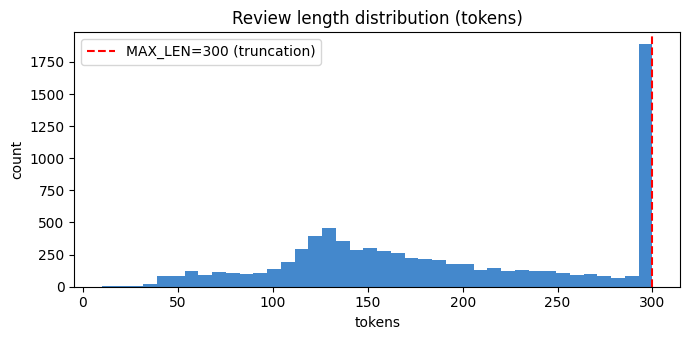

In [ ]:
lengths = [min(len(tokenize(ex['text'])), MAX_LEN) for ex in train_raw]
plt.figure(figsize=(7, 3.5))
plt.hist(lengths, bins=40, color='#48c')
plt.axvline(MAX_LEN, color='red', ls='--', label=f'MAX_LEN={MAX_LEN} (truncation)')
plt.title('Review length distribution (tokens)')
plt.xlabel('tokens'); plt.ylabel('count'); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
def make_loaders(Xtr, ytr, Xva, yva, batch_size=64):
    tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    va = DataLoader(TensorDataset(Xva, yva), batch_size=256, shuffle=False)
    return tr, va

In [ ]:
train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256)

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.6 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

In [ ]:
GLOVE_DIM = 100
print('Downloading GloVe (glove-wiki-gigaword-100)... ~130MB, one-time per session.')
glove = api.load('glove-wiki-gigaword-100')

[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
def build_embedding_matrix(stoi, glove_vectors, dim):
    matrix = np.random.normal(0, 0.1, (len(stoi), dim)).astype('float32')
    matrix[PAD] = 0.0                                    # keep pad row zero
    found = 0
    for word, idx in stoi.items():
        if word in glove_vectors:
            matrix[idx] = glove_vectors[word]; found += 1
    print(f'GloVe coverage: {found}/{len(stoi)} words '
          f'({100*found/len(stoi):.0f}%) missing words keep random init')
    return torch.tensor(matrix)

In [ ]:
glove_matrix = build_embedding_matrix(stoi, glove, GLOVE_DIM)
print('embedding matrix:', tuple(glove_matrix.shape))

GloVe coverage: 18956/20000 words (95%) missing words keep random init
embedding matrix: (20000, 100)


In [ ]:
class RecurrentClassifier(nn.Module):
    def __init__(self, kind='lstm', vocab_size=VOCAB_SIZE, embed_dim=GLOVE_DIM,
                 hidden_size=128, num_layers=1, num_classes=2, dropout=0.0,
                 pretrained=None, freeze_embed=False):
        super().__init__()
        self.kind = kind
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        if pretrained is not None:
            self.embed.weight.data.copy_(pretrained)         # load GloVe
            if freeze_embed:
                self.embed.weight.requires_grad = False      # optionally freeze
        rnn = {'lstm': nn.LSTM, 'rnn': nn.RNN, 'gru': nn.GRU}[kind]
        self.rnn = rnn(embed_dim, hidden_size, num_layers, batch_first=True,
                       dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        lengths = (x != PAD).sum(dim=1).cpu().clamp(min=1)   # true review lengths
        e = self.embed(x)                                    # (batch, seq, embed)
        packed = nn.utils.rnn.pack_padded_sequence(
            e, lengths, batch_first=True, enforce_sorted=False)
        _, state = self.rnn(packed)
        h_n = state[0] if self.kind == 'lstm' else state     # LSTM returns (h,c)
        return self.fc(self.drop(h_n[-1]))

In [ ]:
class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=GLOVE_DIM, num_classes=2,
                 dropout=0.0, pretrained=None, freeze_embed=False):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        if pretrained is not None:
            self.embed.weight.data.copy_(pretrained)
            if freeze_embed:
                self.embed.weight.requires_grad = False
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, 100, kernel_size=k, padding=k // 2) for k in (3, 4, 5)
        ])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(100 * 3, num_classes)

    def forward(self, x):
        e = self.embed(x).transpose(1, 2)                    # (batch, embed, seq)
        feats = [F.relu(c(e)).max(dim=2).values for c in self.convs]
        z = torch.cat(feats, dim=1)                          # (batch, 300)
        return self.fc(self.drop(z))

In [ ]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss_sum += F.cross_entropy(logits, yb, reduction='sum').item()
        correct += (logits.argmax(1) == yb).sum().item()
        tot += yb.size(0)
    return loss_sum / tot, correct / tot

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3,
                weight_decay=0.0, clip=5.0, label='model', verbose=True, patience=3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val, best_state, best_ep, best_train_acc, no_improve = -1.0, None, 0, 0.0, 0
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward()
            if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        tl, ta = evaluate(model, train_loader)
        vl, va = evaluate(model, val_loader)
        for k, v in zip(['train_loss', 'val_loss', 'train_acc', 'val_acc'],
                        [tl, vl, ta, va]):
            hist[k].append(v)
        if verbose:
            print(f'[{label}] epoch {ep+1:2d}/{epochs} | '
                  f'train loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}')
        if va > best_val:                                    # improved -> checkpoint
            best_val, best_ep, best_train_acc = va, ep + 1, ta   # track train@best too
            best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f'  early stop at epoch {ep+1} '
                          f'(no val gain for {patience} epochs)')
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    hist['time'] = time.time() - t0
    hist['best_val'], hist['best_epoch'] = best_val, best_ep
    hist['best_train_acc'] = best_train_acc                  # NEW
    if verbose:
        print(f'  restored best val acc {best_val:.3f} (epoch {best_ep})')
    return hist

In [ ]:
def plot_curves(histories, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        ep = range(1, len(h['train_loss']) + 1)
        ax[0].plot(ep, h['val_loss'], marker='o', label=name)
        ax[1].plot(ep, h['val_acc'],  marker='o', label=name)
    ax[0].set(title='Validation loss', xlabel='epoch', ylabel='loss')
    ax[1].set(title='Validation accuracy', xlabel='epoch', ylabel='accuracy')
    for a in ax: a.legend(); a.grid(alpha=0.3)
    plt.suptitle(title); plt.tight_layout(); plt.show()

In [ ]:
set_seed(0)
lstm = RecurrentClassifier(kind='lstm', hidden_size=128, dropout=0.3,
                           pretrained=glove_matrix)
print('LSTM trainable params:', count_params(lstm))
hist_lstm = train_model(lstm, train_loader, val_loader, epochs=15, label='LSTM')
test_loss, test_acc = evaluate(lstm, test_loader)
print(f'\nBaseline LSTM test accuracy: {test_acc:.3f}')

LSTM trainable params: 2118018
[LSTM] epoch  1/15 | train loss 0.568 acc 0.720 | val loss 0.583 acc 0.698
[LSTM] epoch  2/15 | train loss 0.463 acc 0.780 | val loss 0.510 acc 0.747
[LSTM] epoch  3/15 | train loss 0.314 acc 0.873 | val loss 0.441 acc 0.807
[LSTM] epoch  4/15 | train loss 0.220 acc 0.922 | val loss 0.412 acc 0.839
[LSTM] epoch  5/15 | train loss 0.148 acc 0.952 | val loss 0.412 acc 0.828
[LSTM] epoch  6/15 | train loss 0.181 acc 0.933 | val loss 0.503 acc 0.798
[LSTM] epoch  7/15 | train loss 0.055 acc 0.986 | val loss 0.466 acc 0.828
  early stop at epoch 7 (no val gain for 3 epochs)
  restored best val acc 0.839 (epoch 4)

Baseline LSTM test accuracy: 0.824


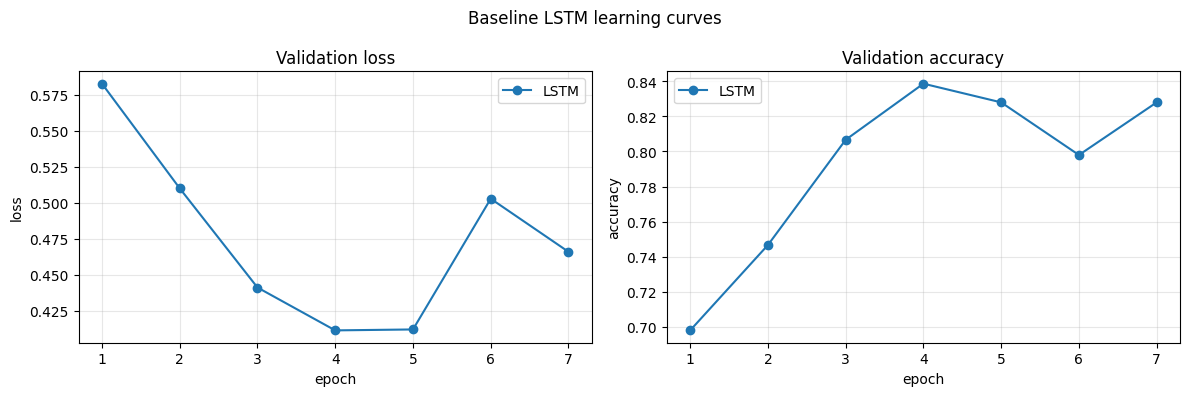

In [ ]:
plot_curves({'LSTM': hist_lstm}, 'Baseline LSTM learning curves')

In [ ]:
lstm.eval()
label_name = {0: 'NEG', 1: 'POS'}
with torch.no_grad():
    idxs = [0, 1, 2, 3, 4, 5]
    probs = F.softmax(lstm(X_test[idxs].to(device)), dim=1).cpu()
    preds = probs.argmax(1)

for row, i in enumerate(idxs):
    txt = test_raw[i]['text'][:160].replace('\n', ' ')
    ok = 'OK ' if preds[row].item() == y_test[i].item() else 'XX '
    print(f"{ok} pred {label_name[preds[row].item()]} "
          f"(p={probs[row, preds[row]].item():.2f}) | "
          f"true {label_name[y_test[i].item()]} | {txt}...")

OK  pred POS (p=0.91) | true POS | This movie was awesome. It's a documentary about how surfing influenced skateboarding in the early days. It has interviews with skaters such as Tony Hawk(my ido...
OK  pred POS (p=0.95) | true POS | When the Italians and Miles O'keeffe work together nothing can go wrong! As ever, Miles is great as the almost as great Ator; the most lovable barbarian of all ...
OK  pred NEG (p=0.96) | true NEG | Forget what I said about Emeril. Rachael Ray is the most irritating personality on the Food Network AND all of television. If you've never seen 30 Minute Meals,...
OK  pred POS (p=0.91) | true POS | This is one of my 3 favorite movies. I've been out on the water since I was 13, so I got a lot of the humor as well as recognizing a lot of the near-land scener...
XX  pred POS (p=0.97) | true NEG | Oh boy ! It was just a dream ! What a great idea ! Mr Lynch is very lucky most people try to tell classical stories. This way he can play with his little planti...
OK  p

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
lstm.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_pred.append(lstm(xb.to(device)).argmax(1).cpu())
        all_true.append(yb)
cm = confusion_matrix(torch.cat(all_true), torch.cat(all_pred))

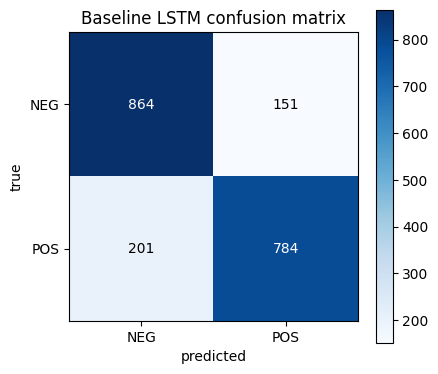

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['NEG', 'POS'],
       yticklabels=['NEG', 'POS'], xlabel='predicted', ylabel='true',
       title='Baseline LSTM confusion matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()

In [ ]:
models = {
    'RNN':  RecurrentClassifier(kind='rnn',  hidden_size=128, dropout=0.3, pretrained=glove_matrix),
    'LSTM': RecurrentClassifier(kind='lstm', hidden_size=128, dropout=0.3, pretrained=glove_matrix),
    'GRU':  RecurrentClassifier(kind='gru',  hidden_size=128, dropout=0.3, pretrained=glove_matrix),
    'CNN':  CNN1DClassifier(dropout=0.3, pretrained=glove_matrix),
}
histories, test_scores = {}, {}
for name, m in models.items():
    set_seed(0)
    histories[name] = train_model(m, train_loader, val_loader, epochs=15,
                                  label=name, verbose=False)
    _, acc = evaluate(m, test_loader)
    test_scores[name] = acc
    print(f'{name:5s} | test acc {acc:.3f} | best val {histories[name]["best_val"]:.3f} '
          f'@ep{histories[name]["best_epoch"]:>2} | params {count_params(m):>9,} | '
          f'{histories[name]["time"]:.1f}s')

RNN   | test acc 0.755 | best val 0.779 @ep 5 | params 2,029,698 | 19.6s
LSTM  | test acc 0.824 | best val 0.837 @ep 7 | params 2,118,018 | 24.6s
GRU   | test acc 0.839 | best val 0.866 @ep 6 | params 2,088,578 | 21.1s
CNN   | test acc 0.854 | best val 0.865 @ep 4 | params 2,120,902 | 11.2s


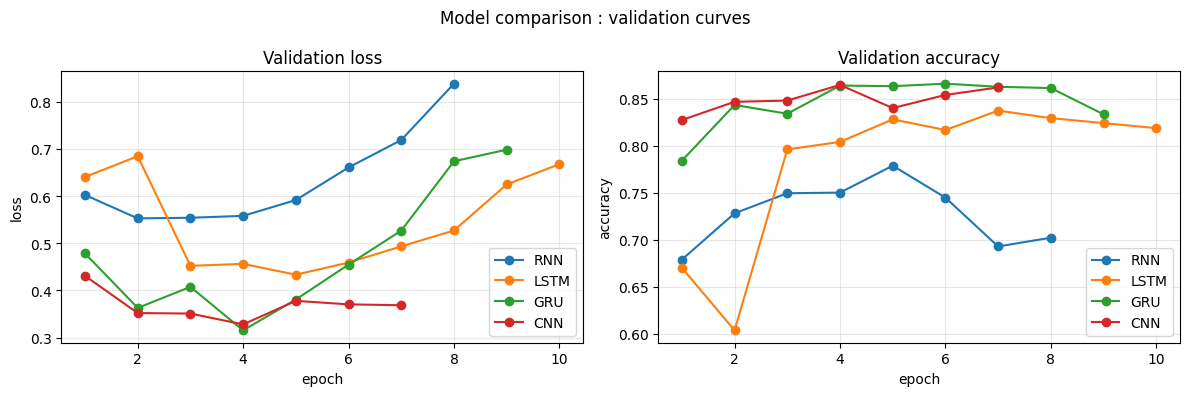

In [ ]:
plot_curves(histories, 'Model comparison : validation curves')

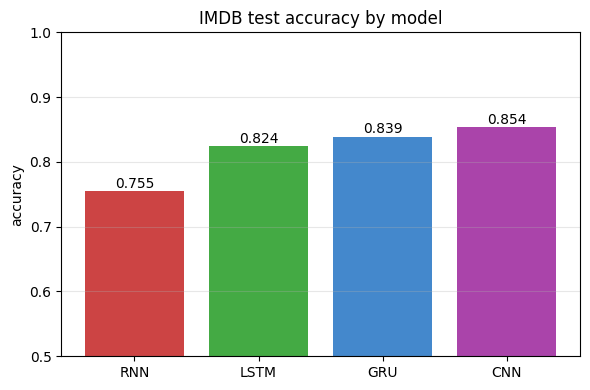

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
names = list(test_scores); accs = [test_scores[n] for n in names]
bars = ax.bar(names, accs, color=['#c44', '#4a4', '#48c', '#a4a'])
ax.set(title='IMDB test accuracy by model', ylabel='accuracy', ylim=(0.5, 1))
for b, a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, a+0.005, f'{a:.3f}', ha='center')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### 7. Where the RNN fails and the LSTM wins long-dependency stress test
We build a task where the answer depends on a word placed FAR from the decision:
 - A polar sentiment word (brilliant / terrible) at position 0.
 - Then T neutral filler tokens.
 - Label = the sentiment of that early word.
The model must carry the early signal across T filler steps. As T grows, the
vanilla RNN forgets (vanishing gradients) while the LSTM's cell state holds.


In [ ]:
POS_WORDS = [w for w in ['brilliant', 'excellent', 'wonderful', 'superb', 'great'] if w in stoi]
NEG_WORDS = [w for w in ['terrible', 'awful', 'horrible', 'boring', 'worst'] if w in stoi]
FILLER    = [w for w in ['the', 'a', 'and', 'of', 'to', 'movie', 'film', 'it'] if w in stoi]
print('polar words available:', POS_WORDS, '/', NEG_WORDS)

polar words available: ['brilliant', 'excellent', 'wonderful', 'superb', 'great'] / ['terrible', 'awful', 'horrible', 'boring', 'worst']


In [ ]:
CUE_POS = stoi.get('brilliant', 2)
CUE_NEG = stoi.get('terrible', 3)
FILLER_IDS = [stoi[w] for w in ['the', 'a', 'and', 'of', 'to', 'it', 'is', 'was'] if w in stoi]
print('cue ids:', CUE_POS, CUE_NEG, '| filler ids:', FILLER_IDS)

cue ids: 499 388 | filler ids: [2, 3, 4, 5, 6, 10, 7, 14]


In [ ]:
def make_longdep_task(n, T):
    # cue at position 0, then T neutral filler tokens. Fixed length, NO padding,
    # so packing reads the true final step and the memory test is clean.
    X = torch.zeros(n, T + 1, dtype=torch.long)
    y = torch.randint(0, 2, (n,))
    for i in range(n):
        X[i, 0] = CUE_POS if y[i] == 1 else CUE_NEG
        X[i, 1:] = torch.tensor([random.choice(FILLER_IDS) for _ in range(T)])
    return X, y

In [ ]:
def run_longdep_experiment(T, epochs=25):
    set_seed(0)
    Xtr, ytr = make_longdep_task(5000, T); Xva, yva = make_longdep_task(1000, T)
    tl = DataLoader(TensorDataset(Xtr, ytr), batch_size=128, shuffle=True)
    vl = DataLoader(TensorDataset(Xva, yva), batch_size=256)
    res = {}
    for kind in ['rnn', 'lstm']:
        set_seed(0)
        m = RecurrentClassifier(kind=kind, embed_dim=32, hidden_size=64)  # learn fresh
        h = train_model(m, tl, vl, epochs=epochs, lr=2e-3,
                        patience=epochs, verbose=False)   # no early stop, full run
        res[kind] = h['best_val']
    return res

In [ ]:
lengths_sweep = [5, 10, 20, 35, 50]
rnn_acc, lstm_acc = [], []
for T in lengths_sweep:
    r = run_longdep_experiment(T)
    rnn_acc.append(r['rnn']); lstm_acc.append(r['lstm'])
    print(f'filler T={T:3d} | RNN acc {r["rnn"]:.3f} | LSTM acc {r["lstm"]:.3f}')

filler T=  5 | RNN acc 1.000 | LSTM acc 1.000
filler T= 10 | RNN acc 1.000 | LSTM acc 1.000
filler T= 20 | RNN acc 1.000 | LSTM acc 1.000
filler T= 35 | RNN acc 1.000 | LSTM acc 1.000
filler T= 50 | RNN acc 0.530 | LSTM acc 0.526


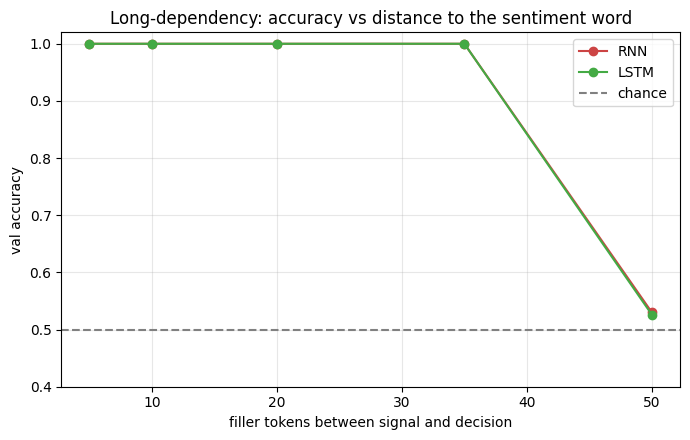

As the signal is buried deeper, the RNN drops toward chance while the
LSTM keeps remembering it the core reason LSTMs beat RNNs.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lengths_sweep, rnn_acc,  'o-', color='#c44', label='RNN')
ax.plot(lengths_sweep, lstm_acc, 'o-', color='#4a4', label='LSTM')
ax.axhline(0.5, ls='--', color='gray', label='chance')
ax.set(title='Long-dependency: accuracy vs distance to the sentiment word',
       xlabel='filler tokens between signal and decision', ylabel='val accuracy',
       ylim=(0.4, 1.02))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('As the signal is buried deeper, the RNN drops toward chance while the')
print('LSTM keeps remembering it the core reason LSTMs beat RNNs.')

In [ ]:
set_seed(0)
small_idx = torch.randperm(len(X_train))[:400]
small_loader = DataLoader(
    TensorDataset(X_train[small_idx], y_train[small_idx]), batch_size=32, shuffle=True)

## 8

In [ ]:
set_seed(0)
model_overfit = RecurrentClassifier(
    kind='lstm', hidden_size=256, num_layers=2,
    dropout=0.0,                       # NO dropout
    pretrained=glove_matrix, freeze_embed=False)   # embeddings trainable
hist_overfit = train_model(
    model_overfit, small_loader, val_loader,
    epochs=25, weight_decay=0.0,       # NO weight decay
    patience=25,                       # effectively no early stopping
    label='OVERFIT', verbose=True)

[OVERFIT] epoch  1/25 | train loss 0.684 acc 0.645 | val loss 0.690 acc 0.554
[OVERFIT] epoch  2/25 | train loss 0.669 acc 0.647 | val loss 0.686 acc 0.566
[OVERFIT] epoch  3/25 | train loss 0.650 acc 0.695 | val loss 0.860 acc 0.614
[OVERFIT] epoch  4/25 | train loss 0.493 acc 0.777 | val loss 0.674 acc 0.603
[OVERFIT] epoch  5/25 | train loss 0.581 acc 0.730 | val loss 1.006 acc 0.565
[OVERFIT] epoch  6/25 | train loss 0.356 acc 0.868 | val loss 0.722 acc 0.590
[OVERFIT] epoch  7/25 | train loss 0.231 acc 0.910 | val loss 0.940 acc 0.589
[OVERFIT] epoch  8/25 | train loss 0.151 acc 0.953 | val loss 1.075 acc 0.617
[OVERFIT] epoch  9/25 | train loss 0.154 acc 0.927 | val loss 1.570 acc 0.606
[OVERFIT] epoch 10/25 | train loss 0.036 acc 0.995 | val loss 1.285 acc 0.603
[OVERFIT] epoch 11/25 | train loss 0.022 acc 0.995 | val loss 1.458 acc 0.631
[OVERFIT] epoch 12/25 | train loss 0.008 acc 1.000 | val loss 1.634 acc 0.619
[OVERFIT] epoch 13/25 | train loss 0.009 acc 0.995 | val loss 2.

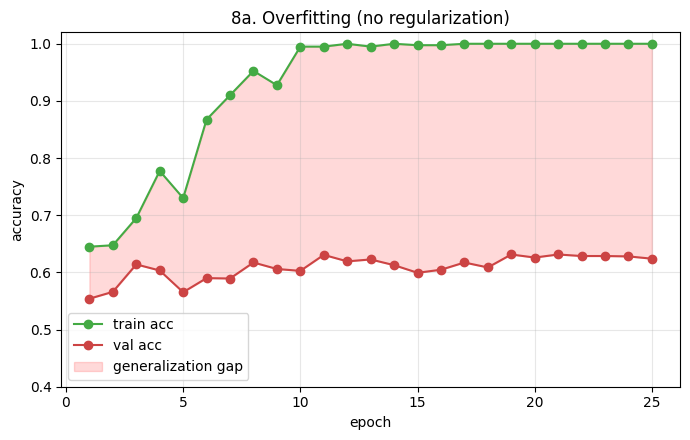

8a  best epoch 19 | train 1.000 | val 0.631 | gap 0.369


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ep = range(1, len(hist_overfit['train_acc']) + 1)
ax.plot(ep, hist_overfit['train_acc'], 'o-', color='#4a4', label='train acc')
ax.plot(ep, hist_overfit['val_acc'],   'o-', color='#c44', label='val acc')
ax.fill_between(ep, hist_overfit['train_acc'], hist_overfit['val_acc'],
                alpha=0.15, color='red', label='generalization gap')
ax.set(title='8a. Overfitting (no regularization)', xlabel='epoch',
       ylabel='accuracy', ylim=(0.4, 1.02))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
gap_overfit = hist_overfit['best_train_acc'] - hist_overfit['best_val']
print(f"8a  best epoch {hist_overfit['best_epoch']} | "
      f"train {hist_overfit['best_train_acc']:.3f} | val {hist_overfit['best_val']:.3f} "
      f"| gap {gap_overfit:.3f}")

In [ ]:
set_seed(0)
model_reg = RecurrentClassifier(
    kind='lstm', hidden_size=256, num_layers=2,
    dropout=0.5,                       # dropout ON
    pretrained=glove_matrix, freeze_embed=True)    # freeze embeddings (fewer params)
hist_reg = train_model(model_reg, small_loader, val_loader,
                       epochs=25, weight_decay=1e-3, patience=4,
                       label='REGULARIZED', verbose=True)

[REGULARIZED] epoch  1/25 | train loss 0.688 acc 0.557 | val loss 0.691 acc 0.546
[REGULARIZED] epoch  2/25 | train loss 0.683 acc 0.562 | val loss 0.689 acc 0.533
[REGULARIZED] epoch  3/25 | train loss 0.673 acc 0.650 | val loss 0.684 acc 0.566
[REGULARIZED] epoch  4/25 | train loss 0.665 acc 0.580 | val loss 0.694 acc 0.565
[REGULARIZED] epoch  5/25 | train loss 0.653 acc 0.593 | val loss 0.690 acc 0.567
[REGULARIZED] epoch  6/25 | train loss 0.628 acc 0.670 | val loss 0.671 acc 0.570
[REGULARIZED] epoch  7/25 | train loss 0.593 acc 0.677 | val loss 0.690 acc 0.618
[REGULARIZED] epoch  8/25 | train loss 0.608 acc 0.670 | val loss 0.680 acc 0.561
[REGULARIZED] epoch  9/25 | train loss 0.583 acc 0.690 | val loss 0.681 acc 0.583
[REGULARIZED] epoch 10/25 | train loss 0.524 acc 0.715 | val loss 0.679 acc 0.629
[REGULARIZED] epoch 11/25 | train loss 0.537 acc 0.725 | val loss 0.676 acc 0.601
[REGULARIZED] epoch 12/25 | train loss 0.506 acc 0.748 | val loss 0.702 acc 0.609
[REGULARIZED] ep

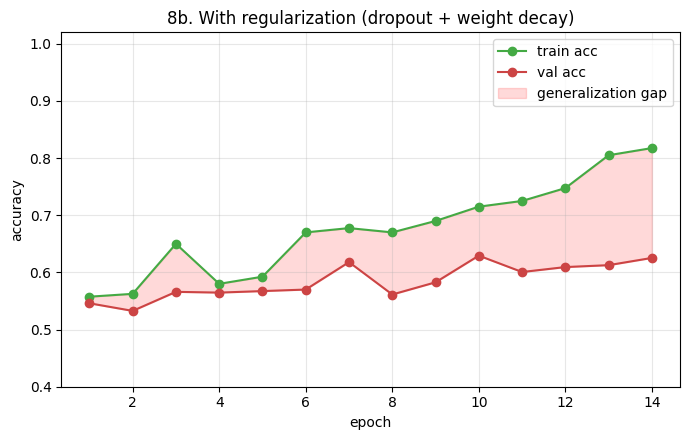

8b  best epoch 10 | train 0.715 | val 0.629 | gap 0.086


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ep = range(1, len(hist_reg['train_acc']) + 1)
ax.plot(ep, hist_reg['train_acc'], 'o-', color='#4a4', label='train acc')
ax.plot(ep, hist_reg['val_acc'],   'o-', color='#c44', label='val acc')
ax.fill_between(ep, hist_reg['train_acc'], hist_reg['val_acc'],
                alpha=0.15, color='red', label='generalization gap')
ax.set(title='8b. With regularization (dropout + weight decay)', xlabel='epoch',
       ylabel='accuracy', ylim=(0.4, 1.02))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
gap_overfit = hist_overfit['best_train_acc'] - hist_overfit['best_val']
gap_reg = hist_reg['best_train_acc'] - hist_reg['best_val']
print(f"8b  best epoch {hist_reg['best_epoch']} | "
      f"train {hist_reg['best_train_acc']:.3f} | val {hist_reg['best_val']:.3f} "
      f"| gap {gap_reg:.3f}")

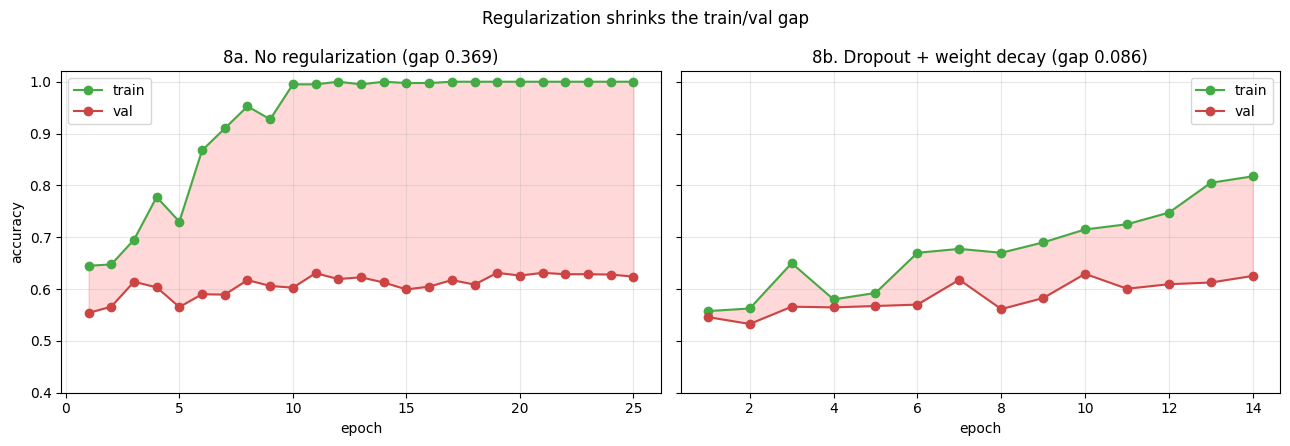

No regularization : gap 0.369
With regularization: gap 0.086
Gap reduced by     : 0.283


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for a, h, t in [(ax[0], hist_overfit, f'8a. No regularization (gap {gap_overfit:.3f})'),
                (ax[1], hist_reg,     f'8b. Dropout + weight decay (gap {gap_reg:.3f})')]:
    ep = range(1, len(h['train_acc']) + 1)
    a.plot(ep, h['train_acc'], 'o-', color='#4a4', label='train')
    a.plot(ep, h['val_acc'],   'o-', color='#c44', label='val')
    a.fill_between(ep, h['train_acc'], h['val_acc'], alpha=0.15, color='red')
    a.set(title=t, xlabel='epoch', ylim=(0.4, 1.02))
    a.legend(); a.grid(alpha=0.3)
ax[0].set_ylabel('accuracy')
plt.suptitle('Regularization shrinks the train/val gap')
plt.tight_layout(); plt.show()

print(f'No regularization : gap {gap_overfit:.3f}')
print(f'With regularization: gap {gap_reg:.3f}')
print(f'Gap reduced by     : {gap_overfit - gap_reg:.3f}')

# Fixing section 7

In [ ]:
class AddingProblemModel(nn.Module):
    """Reads the length-T, 2-channel sequence and predicts the sum (a scalar)."""
    def __init__(self, kind='lstm', hidden_size=64):
        super().__init__()
        self.kind = kind
        rnn = {'lstm': nn.LSTM, 'rnn': nn.RNN}[kind]
        self.rnn = rnn(2, hidden_size, batch_first=True)   # input_size=2 channels
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, state = self.rnn(x)                # x: (batch, T, 2)
        h_n = state[0] if self.kind == 'lstm' else state
        return self.fc(h_n[-1]).squeeze(-1)

In [ ]:
def make_adding_task(n, T):
    """n sequences of length T. Returns X (n,T,2) and y (n,) = sum of 2 marked values."""
    values = torch.rand(n, T)                              # channel 0: random values
    markers = torch.zeros(n, T)                            # channel 1: markers
    y = torch.zeros(n)
    for i in range(n):
        p = torch.randperm(T)[:2]                          # pick 2 distinct positions
        markers[i, p] = 1.0
        y[i] = values[i, p].sum()                          # target = their sum
    X = torch.stack([values, markers], dim=2)              # (n, T, 2)
    return X, y

In [9]:
@torch.no_grad()
def eval_adding(model, X, y, tol=0.04):
    model.eval()
    pred = model(X.to(device)).cpu()
    mse = F.mse_loss(pred, y).item()
    acc = ((pred - y).abs() < tol).float().mean().item()
    return mse, acc

In [10]:
def train_adding(model, Xtr, ytr, Xva, yva, epochs=40, lr=1e-2, batch_size=128):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    best_acc = 0.0
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.mse_loss(model(xb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        _, acc = eval_adding(model, Xva, yva)
        best_acc = max(best_acc, acc)
    return best_acc

In [11]:
def run_adding_experiment(T, epochs=40):
    set_seed(0)
    Xtr, ytr = make_adding_task(6000, T)
    Xva, yva = make_adding_task(1000, T)
    res = {}
    for kind in ['rnn', 'lstm']:
        set_seed(0)
        m = AddingProblemModel(kind=kind, hidden_size=64)
        res[kind] = train_adding(m, Xtr, ytr, Xva, yva, epochs=epochs)
    return res

In [12]:
lengths_sweep = [10, 30, 80, 150]
rnn_acc, lstm_acc = [], []
for T in lengths_sweep:
    r = run_adding_experiment(T)
    rnn_acc.append(r['rnn']); lstm_acc.append(r['lstm'])
    print(f'seq length T={T:3d} | RNN acc {r["rnn"]:.3f} | LSTM acc {r["lstm"]:.3f}')

seq length T= 10 | RNN acc 0.666 | LSTM acc 1.000
seq length T= 30 | RNN acc 0.086 | LSTM acc 1.000
seq length T= 80 | RNN acc 0.101 | LSTM acc 0.993
seq length T=150 | RNN acc 0.087 | LSTM acc 0.981


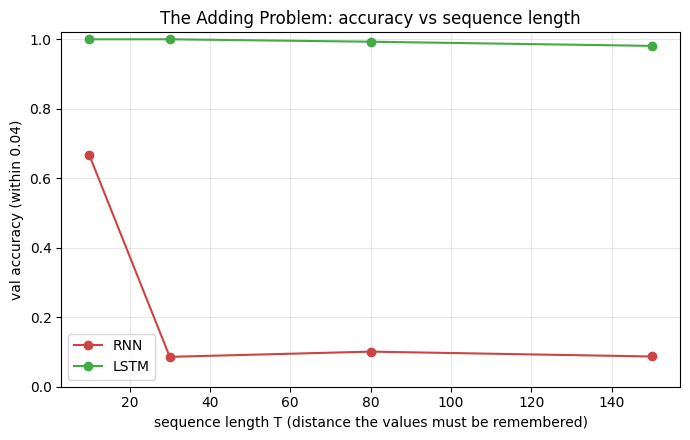

As T grows, the RNN fails to carry the two marked values while the LSTM
still remembers and sums them the classic 1997 result that motivated LSTMs.


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lengths_sweep, rnn_acc,  'o-', color='#c44', label='RNN')
ax.plot(lengths_sweep, lstm_acc, 'o-', color='#4a4', label='LSTM')
ax.set(title='The Adding Problem: accuracy vs sequence length',
       xlabel='sequence length T (distance the values must be remembered)',
       ylabel="val accuracy (within 0.04)", ylim=(0.0, 1.02))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('As T grows, the RNN fails to carry the two marked values while the LSTM')
print('still remembers and sums them the classic 1997 result that motivated LSTMs.')